Dataset files created successfully

Model Accuracy : 92.0 %

Support Vectors:
[48 48]

Classification Report:

              precision    recall  f1-score   support

         Cat       0.95      0.90      0.92        39
         Dog       0.89      0.94      0.92        36

    accuracy                           0.92        75
   macro avg       0.92      0.92      0.92        75
weighted avg       0.92      0.92      0.92        75



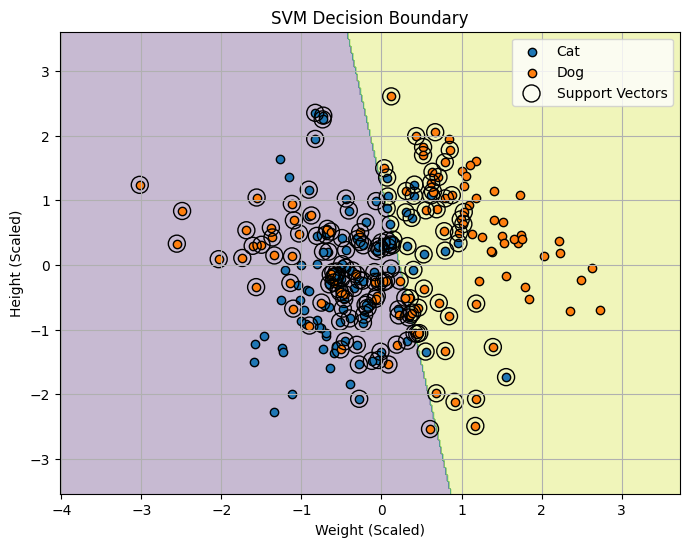

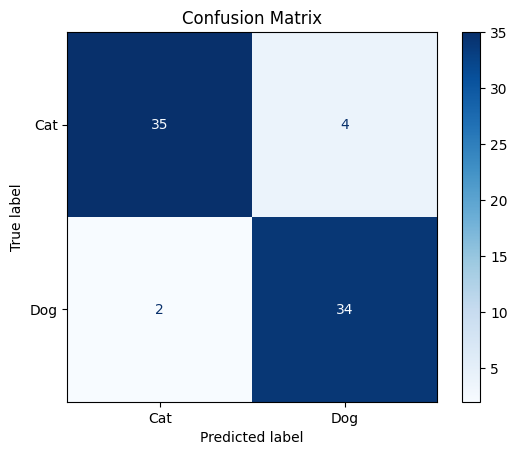

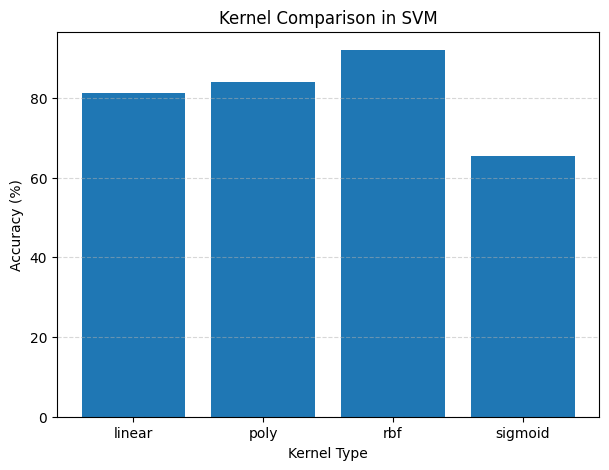

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)



X, y = make_classification(
    n_samples=300,
    n_features=4,
    n_informative=4,
    n_redundant=0,
    random_state=42
)

feature_names = [
    "Weight",
    "Height",
    "Tail_Length",
    "Ear_Length"
]

data = pd.DataFrame(X, columns=feature_names)


data["Animal"] = np.where(y == 0, "Cat", "Dog")



train_data, test_data = train_test_split(
    data,
    test_size=0.25,
    random_state=42
)


train_data.to_csv("dogs_vs_cats_train.csv", index=False)
test_data.to_csv("dogs_vs_cats_test.csv", index=False)

print("Dataset files created successfully")



train_df = pd.read_csv("dogs_vs_cats_train.csv")
test_df = pd.read_csv("dogs_vs_cats_test.csv")



X_train = train_df.drop("Animal", axis=1)
y_train = train_df["Animal"]

X_test = test_df.drop("Animal", axis=1)
y_test = test_df["Animal"]

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy :", round(accuracy * 100, 2), "%")

print("\nSupport Vectors:")
print(svm_model.n_support_)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)


X_visual = X_train[:, :2]
y_visual = y_train

linear_svm = SVC(kernel="linear")

linear_svm.fit(X_visual, y_visual)

x_min = X_visual[:, 0].min() - 1
x_max = X_visual[:, 0].max() + 1

y_min = X_visual[:, 1].min() - 1
y_max = X_visual[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

Z = linear_svm.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)
plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z, alpha=0.3)

for i, animal_name in enumerate(label_encoder.classes_):

    plt.scatter(
        X_visual[y_visual == i, 0],
        X_visual[y_visual == i, 1],
        label=animal_name,
        edgecolors="black"
    )
plt.scatter(
    linear_svm.support_vectors_[:, 0],
    linear_svm.support_vectors_[:, 1],
    s=150,
    facecolors="none",
    edgecolors="black",
    label="Support Vectors"
)

plt.xlabel("Weight (Scaled)")
plt.ylabel("Height (Scaled)")

plt.title("SVM Decision Boundary")

plt.legend()

plt.grid(True)

plt.show()


cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
).plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()


kernel_list = ["linear", "poly", "rbf", "sigmoid"]

accuracy_values = []

for kernel_name in kernel_list:

    temp_model = SVC(
        kernel=kernel_name,
        gamma="scale"
    )

    temp_model.fit(X_train, y_train)

    temp_prediction = temp_model.predict(X_test)

    temp_accuracy = accuracy_score(
        y_test,
        temp_prediction
    ) * 100

    accuracy_values.append(temp_accuracy)

plt.figure(figsize=(7, 5))

plt.bar(kernel_list, accuracy_values)

plt.xlabel("Kernel Type")
plt.ylabel("Accuracy (%)")

plt.title("Kernel Comparison in SVM")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()